In [ ]:
# TODO: list:
# 
# LSTM:
    # work on model architecture 
    # save the model to db with models 
    # create automating loading model once the stock prediction need to be made 
    # once the model is trained I do not want to train it every time because of time consumption, and I want to enhance the model using the latest data 


In [19]:
import numpy as np 
import pandas as pd 
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Data Scrap

## yfinance approach: init db, insert data, update db, add new 

In [7]:
import sqlite3
from datetime import datetime, timedelta
import yfinance as yf


In [11]:
DB_NAME = 'stocks.db'


def initialize_database():
    """
    Create a SQLite database and the stock_data table.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS stock_data (
            stock TEXT,
            date TEXT,
            open REAL,
            high REAL,
            low REAL,
            close REAL,
            volume INTEGER,
            dividends REAL,
            stock_splits REAL,
            PRIMARY KEY (stock, date)
        )
    """)
    conn.commit()
    conn.close()


def insert_data(ticker_symbol, data):
    """
    Insert historical data for a given stock into the database.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    for _, row in data.iterrows():
        cursor.execute("""
            INSERT OR IGNORE INTO stock_data 
            (stock, date, open, high, low, close, volume, dividends, stock_splits)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            ticker_symbol,
            row['Date'].strftime('%Y-%m-%d') if isinstance(row['Date'], (datetime, pd.Timestamp)) else row['Date'],
            row['Open'],
            row['High'],
            row['Low'],
            row['Close'],
            row['Volume'],
            row['Dividends'],
            row['Stock Splits']
        ))
    conn.commit()
    conn.close()


def fetch_missing_data(ticker_symbol, start_date):
    """
    Fetch missing data for a stock from a given start date.
    """

    ticker = yf.Ticker(ticker_symbol)
    data = ticker.history(start=start_date)
    flat_data = data.reset_index()
    flat_data.insert(0, 'stock', ticker_symbol)
    return flat_data


def update_database():
    """
    Check if stock data is up to date and fetch missing data if needed.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT DISTINCT stock FROM stock_data")
    stocks = cursor.fetchall()
    stocks = [stock[0] for stock in stocks]
    
    for stock in stocks:
        cursor.execute("""
            SELECT MAX(date) FROM stock_data WHERE stock = ?
        """, (stock,))
        result = cursor.fetchone()
        last_date = result[0]
        
        if last_date:
            last_date = datetime.strptime(last_date, '%Y-%m-%d').date()
            if last_date < datetime.now().date() - timedelta(days=1):
                print(f"Updating data for {stock}...")
                missing_start = last_date + timedelta(days=1)
                new_data = fetch_missing_data(stock, missing_start)
                insert_data(stock, new_data)
    
    conn.close()


def add_new_stock(ticker_symbol):
    """
    Add a new stock's data to the database.
    """

    print(f"Fetching data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    historical_data = ticker.history(period='max')
    flat_data = historical_data.reset_index()
    flat_data.insert(0, 'stock', ticker_symbol)
    insert_data(ticker_symbol, flat_data)


def get_data_from_db(ticker_symbol, start_date, end_date):
    # TODO: if start_date is == 'full' then get all the historicla data -> date <= end_date

    """
    Fetch data for a given ticker symbol and date range from the database.

    Parameters:
        ticker_symbol (str): The stock symbol to fetch data for.
        start_date (str): The start date in 'YYYY-MM-DD' format.
        end_date (str): The end date in 'YYYY-MM-DD' format.
    """

    conn = sqlite3.connect(DB_NAME)
    query = """
        SELECT * FROM stock_data
        WHERE stock = ? AND date BETWEEN ? AND ?
        ORDER BY date ASC
    """
    data = pd.read_sql_query(query, conn, params=(ticker_symbol, start_date, end_date))
    conn.close()

    # data['date'] = pd.to_datetime(data['date'])
    return data

In [339]:
# initialize_database()
# add_new_stock('NVDA')
update_database()

Updating data for AAPL...
Updating data for MSFT...
Updating data for NVDA...


# Preprocessing

## Download input from DB 

In [82]:
df_test = get_data_from_db('NVDA', '2019-01-01', '2025-01-02')

In [83]:
df_test

,stock,date,open,high,low,close,volume,dividends,stock_splits
0,NVDA,2019-01-02,3.239713,3.434136,3.225082,3.378090,508752000,0.0,0.0
1,NVDA,2019-01-03,3.317828,3.351803,3.166556,3.173995,705552000,0.0,0.0
2,NVDA,2019-01-04,3.247152,3.415536,3.216402,3.377346,585620000,0.0,0.0
3,NVDA,2019-01-07,3.434631,3.593096,3.383298,3.556145,709160000,0.0,0.0
4,NVDA,2019-01-08,3.637733,3.639965,3.394953,3.467613,786016000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1505,NVDA,2024-12-24,140.000000,141.899994,138.649994,140.220001,105157000,0.0,0.0
1506,NVDA,2024-12-26,139.699997,140.850006,137.729996,139.929993,116205600,0.0,0.0
1507,NVDA,2024-12-27,138.550003,139.020004,134.710007,137.009995,170291000,0.0,0.0
1508,NVDA,2024-12-30,134.830002,140.270004,134.020004,137.490005,167734700,0.0,0.0


## Split and Normzlize 

In [84]:
def split_data(data, train_ratio=0.8):
    """
    Split data into training and validation sets using train_test_split.

    Parameters:
        data (DataFrame): The stock data.
        train_ratio (float): The proportion of data to use for training.
    """

    train_data, validation_data = train_test_split(data, train_size=train_ratio, shuffle=False)
    return train_data, validation_data


def normalize_data(train_data, validation_data):
    """
    Normalize training and validation sets using MinMaxScaler.

    Parameters:
        train_data (DataFrame): Training data.
        validation_data (DataFrame): Validation data.
    """
    columns_to_normalize = ['open', 'high', 'low', 'close']

    scaler = MinMaxScaler(feature_range=(0, 1))
    
    scaler.fit(train_data[columns_to_normalize])
    
    train_data_normalized = train_data.copy()
    validation_data_normalized = validation_data.copy()
    
    train_data_normalized[columns_to_normalize] = scaler.transform(train_data[columns_to_normalize])
    validation_data_normalized[columns_to_normalize] = scaler.transform(validation_data[columns_to_normalize])
    
    
    return train_data_normalized, validation_data_normalized, scaler

In [85]:
train_df_test, validation_df_test = split_data(df_test)

In [342]:
train_df_test

,stock,date,open,high,low,close,volume,dividends,stock_splits
0,NVDA,2019-01-02,3.239713,3.434136,3.225082,3.378090,508752000,0.0,0.0
1,NVDA,2019-01-03,3.317828,3.351803,3.166556,3.173995,705552000,0.0,0.0
2,NVDA,2019-01-04,3.247152,3.415536,3.216402,3.377346,585620000,0.0,0.0
3,NVDA,2019-01-07,3.434631,3.593096,3.383298,3.556145,709160000,0.0,0.0
4,NVDA,2019-01-08,3.637733,3.639965,3.394953,3.467613,786016000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1203,NVDA,2023-10-12,46.759630,47.591321,46.312797,46.927567,481325000,0.0,0.0
1204,NVDA,2023-10-13,46.942559,47.098503,45.263182,45.444115,474115000,0.0,0.0
1205,NVDA,2023-10-16,45.046270,46.207837,44.895325,46.077888,375099000,0.0,0.0
1206,NVDA,2023-10-17,43.983662,44.737383,42.464225,43.921684,812333000,0.0,0.0


In [348]:
validation_df_test

,stock,date,open,high,low,close,volume,dividends,stock_splits
1208,NVDA,2023-10-19,42.795105,43.280924,41.866449,42.085369,501233000,0.0,0.0
1209,NVDA,2023-10-20,41.874443,42.454230,41.062744,41.371632,477266000,0.0,0.0
1210,NVDA,2023-10-23,41.213695,43.231947,40.929800,42.959045,478530000,0.0,0.0
1211,NVDA,2023-10-24,43.061005,43.680774,42.675150,43.646786,401463000,0.0,0.0
1212,NVDA,2023-10-25,43.381879,43.633788,41.539565,41.763481,398379000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1505,NVDA,2024-12-24,140.000000,141.899994,138.649994,140.220001,105157000,0.0,0.0
1506,NVDA,2024-12-26,139.699997,140.850006,137.729996,139.929993,116205600,0.0,0.0
1507,NVDA,2024-12-27,138.550003,139.020004,134.710007,137.009995,170291000,0.0,0.0
1508,NVDA,2024-12-30,134.830002,140.270004,134.020004,137.490005,167734700,0.0,0.0


In [86]:
train_df_test_scaled, validation_df_test_scaled, scaler = normalize_data(train_df_test, validation_df_test)

In [173]:
train_df_test_scaled.head(10)

,stock,date,open,high,low,close,volume,dividends,stock_splits
0,NVDA,2019-01-02,0.000000,0.001756,0.001279,0.004422,508752000,0.0,0.0
1,NVDA,2019-01-03,0.001664,0.000000,0.000000,0.000000,705552000,0.0,0.0
2,NVDA,2019-01-04,0.000158,0.001359,0.001089,0.004405,585620000,0.0,0.0
3,NVDA,2019-01-07,0.004151,0.005146,0.004736,0.008279,709160000,0.0,0.0
4,NVDA,2019-01-08,0.008477,0.006145,0.004990,0.006361,786016000,0.0,0.0
5,NVDA,2019-01-09,0.005947,0.004934,0.006594,0.007839,617260000,0.0,0.0
6,NVDA,2019-01-10,0.005894,0.005511,0.006323,0.009262,523156000,0.0,0.0
7,NVDA,2019-01-11,0.007230,0.007716,0.008409,0.011196,874764000,0.0,0.0
8,NVDA,2019-01-14,0.008493,0.008620,0.009796,0.012061,730168000,0.0,0.0
9,NVDA,2019-01-15,0.011155,0.009620,0.011617,0.011755,617012000,0.0,0.0


In [104]:
validation_df_test_scaled

,stock,date,open,high,low,close,volume,dividends,stock_splits
1208,NVDA,2023-10-19,0.842437,0.851523,0.845544,0.842993,501233000,0.0,0.0
1209,NVDA,2023-10-20,0.822830,0.833894,0.827984,0.827530,477266000,0.0,0.0
1210,NVDA,2023-10-23,0.808757,0.850479,0.825079,0.861920,478530000,0.0,0.0
1211,NVDA,2023-10-24,0.848101,0.860051,0.863213,0.876820,401463000,0.0,0.0
1212,NVDA,2023-10-25,0.854934,0.859049,0.838402,0.836019,398379000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1505,NVDA,2024-12-24,2.912675,2.954662,2.960142,2.969023,105157000,0.0,0.0
1506,NVDA,2024-12-26,2.906285,2.932270,2.940041,2.962740,116205600,0.0,0.0
1507,NVDA,2024-12-27,2.881793,2.893243,2.874058,2.899480,170291000,0.0,0.0
1508,NVDA,2024-12-30,2.802566,2.919901,2.858983,2.909880,167734700,0.0,0.0


# Model

## Input (windows) preparation

In [362]:
import tensorflow as tf
import json

In [218]:
seq_length = 5
train_targets = train_df_test_scaled['close'].to_numpy()

train_inputs = np.array([
    train_targets[i:i + seq_length]
    for i in range(len(train_targets) - seq_length)
]).reshape(-1, seq_length, 1) 

train_targets_multi_step = np.array([
    train_targets[i + seq_length]
    for i in range(len(train_targets) - seq_length)
]).reshape(-1, 1)

train_df = tf.data.Dataset.from_tensor_slices((train_inputs, train_targets_multi_step)).batch(32)


In [279]:
seq_length = 5
val_targets = validation_df_test_scaled['close'].to_numpy()

val_inputs = np.array([
    val_targets[i:i + seq_length]
    for i in range(len(val_targets) - seq_length)
]).reshape(-1, seq_length, 1) 

val_targets_multi_step = np.array([
    val_targets[i + seq_length]
    for i in range(len(val_targets) - seq_length)
]).reshape(-1, 1)

val_df = tf.data.Dataset.from_tensor_slices((val_inputs, val_targets_multi_step)).batch(32)


## LSTM

In [281]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error


In [355]:
def build_lstm_model():
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=(5, 1)),
        LSTM(32, activation='relu', return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    training_params = {
    "batch_size": 32,
    "epochs": 200,
    "validation_data": True
    }

    return model, training_params

model, training_params = build_lstm_model()
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [356]:
history = model.fit(
    # https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit

    train_df, # x and y as there is tf.data.Dataset
    batch_size=training_params["batch_size"],
    epochs=training_params["epochs"],
    verbose=1, # progress bar
    validation_data=val_df # tf.data.Dataset

)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0083 - val_loss: 0.0230
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0361 - val_loss: 0.0953
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092 - val_loss: 0.0168
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181 - val_loss: 0.2256
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 0.0188
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041 - val_loss: 0.0178
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 0.0358
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 0.0840
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_loss: 0.1053
Epoch 10/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.8814e-04 - val_loss: 0.1205
Epoch 11/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2516e-04 - val_loss: 0.0977
Epoch 12/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

In [357]:
def extract_model_architecture(model, training_params):
    """
    Extracts model architecture and training parameters dynamically.
    Parameters:
        model: The trained Keras model.
        training_params: Dictionary containing training parameters like batch_size and epochs.
    Returns:
        dict: Model architecture and training parameters in a dictionary.
    """

    model_config = model.get_config()
    layers = []
    for layer in model_config['layers']:
        layer_info = {
            'type': layer['class_name'],
            'config': layer['config']
        }
        layers.append(layer_info)
    
    optimizer_config = model.optimizer.get_config()
    
    model_architecture = {
        "layers": layers,
        "optimizer": optimizer_config,
        "loss": model.loss,
        "training_params": training_params
    }
    return model_architecture

In [358]:
model_architecture = extract_model_architecture(model, training_params)

In [284]:
train_predictions = model.predict(train_df)
val_predictions = model.predict(val_df)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [304]:
def denormalize_predictions(predictions, scaler):
    """
    Denormalize predictions using the fitted scaler.
    Create a placeholder array with the same number of features as the scaler was fitted on,
    Insert the predictions into the 'close' column position (index 3 in this case),
    Extract the denormalized 'close' column

    Parameters:
        predictions: Normalized predictions for the 'close' column (2D array of shape (n, 1)).
        scaler (MinMaxScaler): Fitted scaler.

    """
    
    placeholder = np.zeros((predictions.shape[0], len(scaler.feature_names_in_)))
    placeholder[:, -1] = predictions.flatten()
    denorm_placeholder = scaler.inverse_transform(placeholder)
    denorm_predictions = denorm_placeholder[:, -1]
    return denorm_predictions

In [305]:
train_predictions_denorm = denormalize_predictions(train_predictions, scaler)
val_predictions_denorm = denormalize_predictions(val_predictions, scaler)

In [311]:
def calculate_rmse(train_predictions, val_predictions, df_test):
    """
    Calculate RMSE for the training and validation sets.

    Parameters:
        train_predictions (numpy array): Denormalized predicted values for training set.
        val_predictions (numpy array): Denormalized predicted values for validation set.
        df_test (DataFrame): Original dataset with 'close' column.
    """

    close_true_train = df_test['close'].iloc[:len(train_predictions)].values
    close_true_val = df_test['close'].iloc[len(train_predictions):len(train_predictions) + len(val_predictions)].values

    train_rmse = np.sqrt(mean_squared_error(close_true_train, train_predictions))
    val_rmse = np.sqrt(mean_squared_error(close_true_val, val_predictions))

    return train_rmse, val_rmse

In [312]:
train_rmse, val_rmse = calculate_rmse(train_predictions_denorm, val_predictions_denorm, df_test)

In [313]:
train_rmse

1.0136868266482069

In [314]:
val_rmse

9.750648212429699

In [ ]:
# TODO: model perform much batter on train dataset: big overfitting, maybe use some normalization? 

In [363]:
def create_prediction_dataframe(train_predictions, val_predictions, df_test, train_rmse, val_rmse, seq_length, model_architecture):
    """
    Create a dataframe with true and predicted values, along with additional metadata,
    and assign RMSE values for train and validation rows.

    Parameters:
        train_predictions (numpy array): Denormalized predicted values for training set.
        val_predictions (numpy array): Denormalized predicted values for validation set.
        df_test (DataFrame): Original dataset with stock, date, and close.
        train_rmse (float): RMSE value for the training set.
        val_rmse (float): RMSE value for the validation set.

    """

    train_predictions = train_predictions.flatten()
    val_predictions = val_predictions.flatten()
    
    train_start_idx = seq_length
    val_start_idx = seq_length + len(train_predictions)

    stocks_train = df_test['stock'].iloc[train_start_idx:train_start_idx + len(train_predictions)].values
    stocks_val = df_test['stock'].iloc[val_start_idx:val_start_idx + len(val_predictions)].values

    dates_train = df_test['date'].iloc[train_start_idx:train_start_idx + len(train_predictions)].values
    dates_val = df_test['date'].iloc[val_start_idx:val_start_idx + len(val_predictions)].values

    close_true_train = df_test['close'].iloc[train_start_idx:train_start_idx + len(train_predictions)].values
    close_true_val = df_test['close'].iloc[val_start_idx:val_start_idx + len(val_predictions)].values

    combined_data = {
        'stock': np.concatenate([stocks_train, stocks_val]),
        'date': np.concatenate([dates_train, dates_val]),
        'close_true': np.concatenate([close_true_train, close_true_val]),
        'close_predicted': np.concatenate([train_predictions, val_predictions]),
        'dataset_point': ['train'] * len(train_predictions) + ['val'] * len(val_predictions),
        'model_version': ['1.0.0'] * (len(train_predictions) + len(val_predictions)),
        'rmse_value': [train_rmse] * len(train_predictions) + [val_rmse] * len(val_predictions),
        'model_architecture': [json.dumps(model_architecture)] * (len(train_predictions) + len(val_predictions)),
    }

    df = pd.DataFrame(combined_data)
    return df


In [365]:
prediction_df = create_prediction_dataframe(
    train_predictions_denorm, val_predictions_denorm, df_test, train_rmse, val_rmse, seq_length, model_architecture
)


5
1208


In [366]:
prediction_df

,stock,date,close_true,close_predicted,train_or_val_row,model_version,rmse_value,model_architecture
0,NVDA,2019-01-09,3.535810,3.815502,train,1.0.0,1.013687,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1,NVDA,2019-01-10,3.601527,3.844466,train,1.0.0,1.013687,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
2,NVDA,2019-01-11,3.690802,3.897550,train,1.0.0,1.013687,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
3,NVDA,2019-01-14,3.730728,3.943911,train,1.0.0,1.013687,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
4,NVDA,2019-01-15,3.716593,3.976002,train,1.0.0,1.013687,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
...,...,...,...,...,...,...,...,...
1495,NVDA,2024-12-17,130.389999,128.484112,val,1.0.0,9.750648,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1496,NVDA,2024-12-18,133.490097,127.663629,val,1.0.0,9.750648,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1497,NVDA,2024-12-19,130.679993,128.447707,val,1.0.0,9.750648,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."
1498,NVDA,2024-12-20,134.699997,125.361610,val,1.0.0,9.750648,"{""layers"": [{""type"": ""InputLayer"", ""config"": {..."


# Store output

## Save model 

In [369]:
import os

def save_model(model, version, folder="models"):
    """
    Save the trained model to the specified folder with version name in the filename.

    Parameters:
        model (tf.keras.Model): The trained Keras model to save.
        version (str): The version name (e.g., '1.0.0') to include in the filename.
        folder (str): The folder where the model will be saved. Defaults to 'models'.
    """

    if not os.path.exists(folder):
        os.makedirs(folder)

    filename = f"model_v{version}.h5"
    filepath = os.path.join(folder, filename)

    model.save(filepath)

In [370]:
model_version = "1.0.0"
save_model(model, model_version)

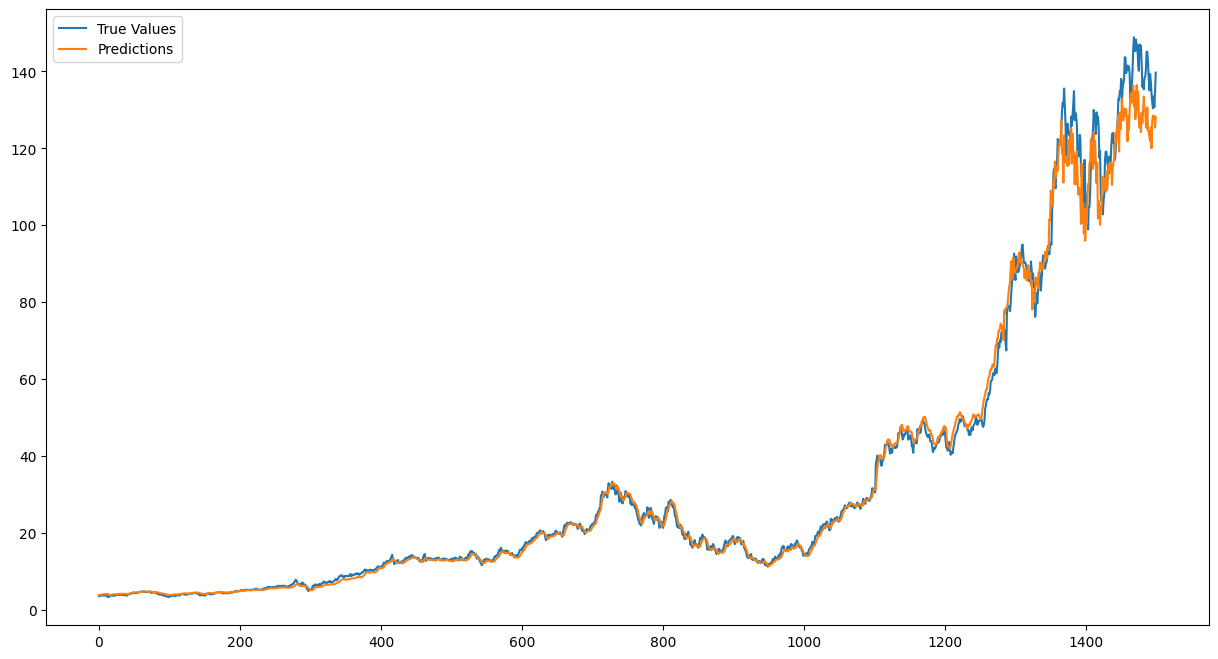

In [341]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
plt.plot(prediction_df['close_true'], label="True Values")
plt.plot(prediction_df['close_predicted'], label="Predictions")
plt.legend()
plt.show()

# Tests

## Operating on created DB

In [ ]:
def print_top_records():
    """
    Fetch and print the top 10 records from the stock_data table.
    """
    
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    query = "SELECT * FROM stock_data LIMIT 100;"
    cursor.execute(query)  

    records = cursor.fetchall()
    column_names = [description[0] for description in cursor.description]
    df = pd.DataFrame(records, columns=column_names)
    print(df)
    
    conn.close()

print_top_records()

   stock        date      open      high       low     close      volume  \
0   MSFT  1986-03-13  0.054485  0.062498  0.054485  0.059827  1031788800   
1   MSFT  1986-03-14  0.059827  0.063032  0.059827  0.061963   308160000   
2   MSFT  1986-03-17  0.061963  0.063566  0.061963  0.063032   133171200   
3   MSFT  1986-03-18  0.063032  0.063566  0.060895  0.061429    67766400   
4   MSFT  1986-03-19  0.061429  0.061963  0.059827  0.060361    47894400   
..   ...         ...       ...       ...       ...       ...         ...   
95  MSFT  1986-07-29  0.065169  0.065703  0.062498  0.063566    14054400   
96  MSFT  1986-07-30  0.063566  0.063566  0.059293  0.061429    26409600   
97  MSFT  1986-07-31  0.061429  0.061963  0.060895  0.060895    15638400   
98  MSFT  1986-08-01  0.060895  0.061429  0.059827  0.060361    12902400   
99  MSFT  1986-08-04  0.060361  0.060361  0.058758  0.060361    12441600   

    dividends  stock_splits  
0         0.0           0.0  
1         0.0           0.0

## Train and Val vs Normalized Train and Val 

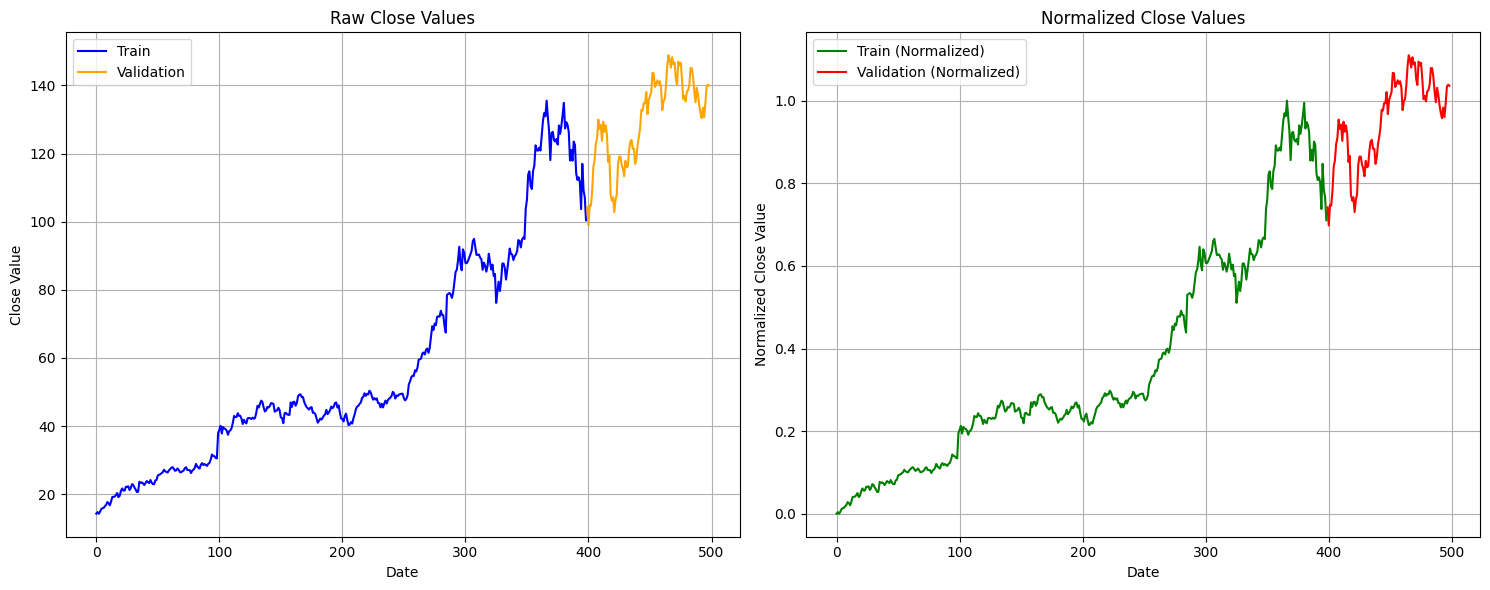

In [37]:
import matplotlib.pyplot as plt

def plot_raw_and_normalized(train_data, validation_data, train_normalized, validation_normalized):
    """
    Create a subplot with raw and normalized close values for train and validation datasets.
    """

    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    axs[0].plot(train_data.index, train_data['close'], label='Train', color='blue')
    axs[0].plot(validation_data.index, validation_data['close'], label='Validation', color='orange')
    axs[0].set_title("Raw Close Values")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Close Value")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(train_normalized.index, train_normalized['close'], label='Train (Normalized)', color='green')
    axs[1].plot(validation_normalized.index, validation_normalized['close'], label='Validation (Normalized)', color='red')
    axs[1].set_title("Normalized Close Values")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Normalized Close Value")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_raw_and_normalized(train_df_test, validation_df_test, train_df_test_scaled, validation_df_test_scaled)